# 03 — Análisis avanzado con window functions

**Proyecto:** BRFSS 2015 — Análisis SQL de Riesgo de Diabetes  
**Repositorio:** https://github.com/Jesusrodriguezf90/brfss2015-diabetes-sql-analysis  
**Fase:** Análisis avanzado — window functions y hallazgos clave

---

Análisis avanzado con `PERCENT_RANK()`, `ROW_NUMBER()` y `PARTITION BY` sobre el dataset BRFSS 2015.
Se calculan percentiles de consumo de dieta por clase y rankings de prevalencia por grupo de edad,
particionados por sexo. El notebook cierra con los hallazgos clave cuantificados del análisis completo.

In [ ]:
"""
Notebook: 03_advanced_sql.ipynb

Objetivo:
    Análisis avanzado con window functions sobre el dataset BRFSS 2015.
    Percentiles de dieta por clase (PERCENT_RANK) y ranking de grupos
    de edad por prevalencia particionado por sexo (ROW_NUMBER + PARTITION BY).
    Cierra con los hallazgos clave cuantificados del análisis completo.

Autor:   Jesús Rodríguez
Fecha:   2026-06-11
Versión: 1.0.0
"""

## 0. Setup

In [ ]:
# Importaciones
import warnings

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo global de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print(f'DuckDB {duckdb.__version__} | pandas {pd.__version__}')

DuckDB 1.5.3 | pandas 3.0.3


In [ ]:
# URL pública del dataset preprocesado en HF Hub
URL_DATASET = 'hf://datasets/Jesusrodriguezf90/brfss2015-diabetes-detection/cleaned_dataset.csv'

# Carga del dataset y registro en DuckDB
df  = pd.read_csv(URL_DATASET)
con = duckdb.connect()
con.register('brfss', df)

print(f'[OK] Dataset cargado: {df.shape[0]:,} registros · {df.shape[1]} columnas')

[OK] Dataset cargado: 257,709 registros · 23 columnas


## 1. Percentiles de dieta por clase

`PERCENT_RANK()` calcula la posición relativa de cada registro dentro de su partición — devuelve
un valor entre 0 y 1 que indica el porcentaje de filas con un valor inferior.
Se calculan los percentiles P25, P50 y P75 de consumo de fruta y verdura,
particionados por clase diabética, para comparar las distribuciones entre grupos.

In [7]:
# Percentiles P25, P50 y P75 de consumo de fruta y verdura por clase
# PERCENT_RANK() sobre la partición de cada clase — sin necesidad de subqueries adicionales
resultado_percentiles = con.execute("""
    WITH ranked AS (
        SELECT
            CASE WHEN DIABETE3 = 1.0 THEN 'Diabético' ELSE 'No diabético' END AS clase,
            _FRUTSUM,
            _VEGESUM,
            PERCENT_RANK() OVER (PARTITION BY DIABETE3 ORDER BY _FRUTSUM) AS prank_fruta,
            PERCENT_RANK() OVER (PARTITION BY DIABETE3 ORDER BY _VEGESUM) AS prank_verdura
        FROM brfss
    )
    SELECT
        clase,
        ROUND(MIN(CASE WHEN prank_fruta   >= 0.25 THEN _FRUTSUM END), 3) AS fruta_p25,
        ROUND(MIN(CASE WHEN prank_fruta   >= 0.50 THEN _FRUTSUM END), 3) AS fruta_p50,
        ROUND(MIN(CASE WHEN prank_fruta   >= 0.75 THEN _FRUTSUM END), 3) AS fruta_p75,
        ROUND(MIN(CASE WHEN prank_verdura >= 0.25 THEN _VEGESUM END), 3) AS verdura_p25,
        ROUND(MIN(CASE WHEN prank_verdura >= 0.50 THEN _VEGESUM END), 3) AS verdura_p50,
        ROUND(MIN(CASE WHEN prank_verdura >= 0.75 THEN _VEGESUM END), 3) AS verdura_p75
    FROM ranked
    GROUP BY clase
    ORDER BY clase DESC
""").df()

print('-' * 76)
print(f"{'Clase':<14} {'Fruta P25':>10} {'Fruta P50':>10} {'Fruta P75':>10} {'Verdur P25':>10} {'Verdur P50':>10} {'Verdur P75':>10}")
print('-' * 76)
for _, row in resultado_percentiles.iterrows():
    print(
        f"{row['clase']:<14}"
        f"{row['fruta_p25']:>10.3f}"
        f"{row['fruta_p50']:>10.3f}"
        f"{row['fruta_p75']:>10.3f}"
        f"{row['verdura_p25']:>10.3f}"
        f"{row['verdura_p50']:>10.3f}"
        f"{row['verdura_p75']:>10.3f}"
    )
print('-' * 76)

----------------------------------------------------------------------------
Clase           Fruta P25  Fruta P50  Fruta P75 Verdur P25 Verdur P50 Verdur P75
----------------------------------------------------------------------------
No diabético       0.690     1.110     2.020     1.220     1.840     2.590
Diabético          0.580     1.020     2.020     1.110     1.680     2.440
----------------------------------------------------------------------------


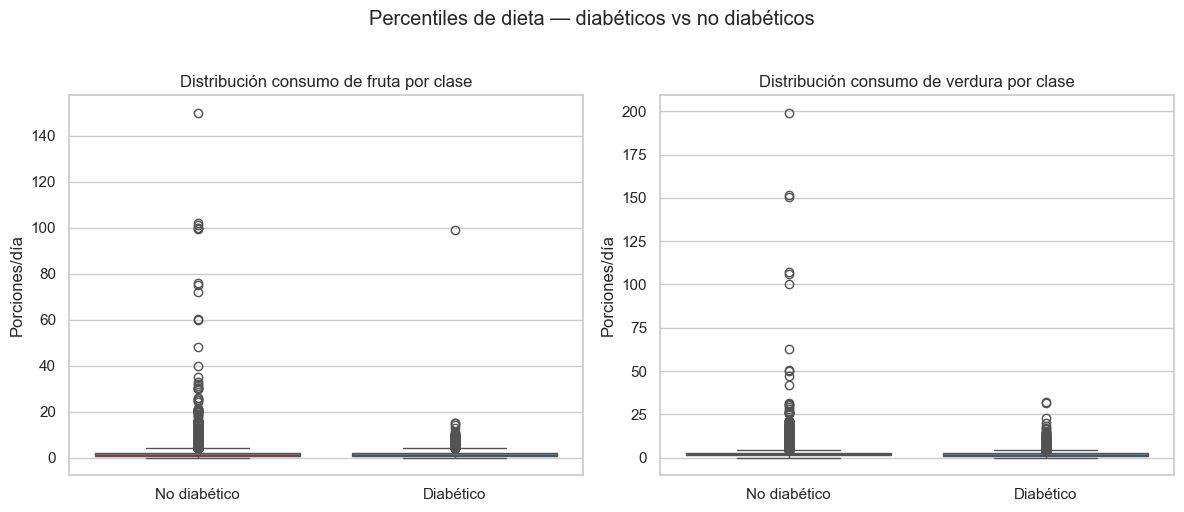

In [8]:
# Visualización — boxplot de distribución de dieta por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Recodificar clase para visualización
df['clase'] = df['DIABETE3'].map({1.0: 'Diabético', 3.0: 'No diabético'})

sns.boxplot(data=df, x='clase', y='_FRUTSUM', ax=axes[0], palette=['#F44336', '#2196F3'])
axes[0].set_title('Distribución consumo de fruta por clase')
axes[0].set_xlabel('')
axes[0].set_ylabel('Porciones/día')

sns.boxplot(data=df, x='clase', y='_VEGESUM', ax=axes[1], palette=['#F44336', '#2196F3'])
axes[1].set_title('Distribución consumo de verdura por clase')
axes[1].set_xlabel('')
axes[1].set_ylabel('Porciones/día')

plt.suptitle('Percentiles de dieta — diabéticos vs no diabéticos', y=1.02)
plt.tight_layout()
plt.show()

# Limpiar columna auxiliar
df.drop(columns=['clase'], inplace=True)

## 2. Ranking de grupos de edad por prevalencia

`ROW_NUMBER()` con `PARTITION BY` asigna un ranking independiente dentro de cada partición.
Se rankean los grupos de edad por prevalencia de diabetes de forma separada para hombres y mujeres,
lo que permite identificar en qué grupos el riesgo es mayor dentro de cada sexo.

> Los hombres presentan una prevalencia consistentemente superior a las mujeres en todos
> los grupos de edad — el grupo 75-79 masculino alcanza el 22.9% frente al 16.4% femenino.

In [12]:
# Ranking de grupos de edad por prevalencia de diabetes, particionado por sexo
# ROW_NUMBER() asigna posición 1 al grupo con mayor prevalencia dentro de cada sexo
# Se filtran valores -1 de _AGEG5YR y se muestran solo los 5 primeros por sexo
resultado_ranking = con.execute("""
    WITH prevalencia_por_grupo AS (
        SELECT
            CASE SEX
                WHEN 1 THEN 'Masculino'
                WHEN 2 THEN 'Femenino'
            END                                                              AS sexo,
            CASE _AGEG5YR
                WHEN 1  THEN '18-24'
                WHEN 2  THEN '25-29'
                WHEN 3  THEN '30-34'
                WHEN 4  THEN '35-39'
                WHEN 5  THEN '40-44'
                WHEN 6  THEN '45-49'
                WHEN 7  THEN '50-54'
                WHEN 8  THEN '55-59'
                WHEN 9  THEN '60-64'
                WHEN 10 THEN '65-69'
                WHEN 11 THEN '70-74'
                WHEN 12 THEN '75-79'
                WHEN 13 THEN '80+'
            END                                                              AS grupo_edad,
            COUNT(*)                                                         AS n_total,
            ROUND(
                SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
            )                                                                AS prevalencia_pct
        FROM brfss
        WHERE _AGEG5YR != -1.0
        GROUP BY SEX, _AGEG5YR
    ),
    ranking AS (
        SELECT
            sexo,
            grupo_edad,
            n_total,
            prevalencia_pct,
            ROW_NUMBER() OVER (PARTITION BY sexo ORDER BY prevalencia_pct DESC) AS rank_sexo
        FROM prevalencia_por_grupo
    )
    SELECT *
    FROM ranking
    WHERE rank_sexo <= 5
    ORDER BY sexo DESC, rank_sexo
""").df()

print('-' * 60)
print(f"{'Sexo':<12} {'Rank':>5} {'Grupo edad':<12} {'N total':>10} {'Prevalencia':>12}")
print('-' * 60)
for _, row in resultado_ranking.iterrows():
    print(
        f"{row['sexo']:<12}"
        f"{int(row['rank_sexo']):>5}"
        f"  {row['grupo_edad']:<12}"
        f"{int(row['n_total']):>10,}"
        f"{row['prevalencia_pct']:>11.1f}%"
    )
print('-' * 60)

------------------------------------------------------------
Sexo          Rank Grupo edad      N total  Prevalencia
------------------------------------------------------------
Masculino       1  75-79            6,040       22.9%
Masculino       2  70-74            9,550       22.5%
Masculino       3  65-69           13,345       20.3%
Masculino       4  80+              6,441       20.0%
Masculino       5  60-64           13,367       16.5%
Femenino        1  75-79            8,904       16.4%
Femenino        2  70-74           12,458       16.1%
Femenino        3  65-69           16,531       15.2%
Femenino        4  80+             10,468       13.9%
Femenino        5  60-64           16,515       13.5%
------------------------------------------------------------


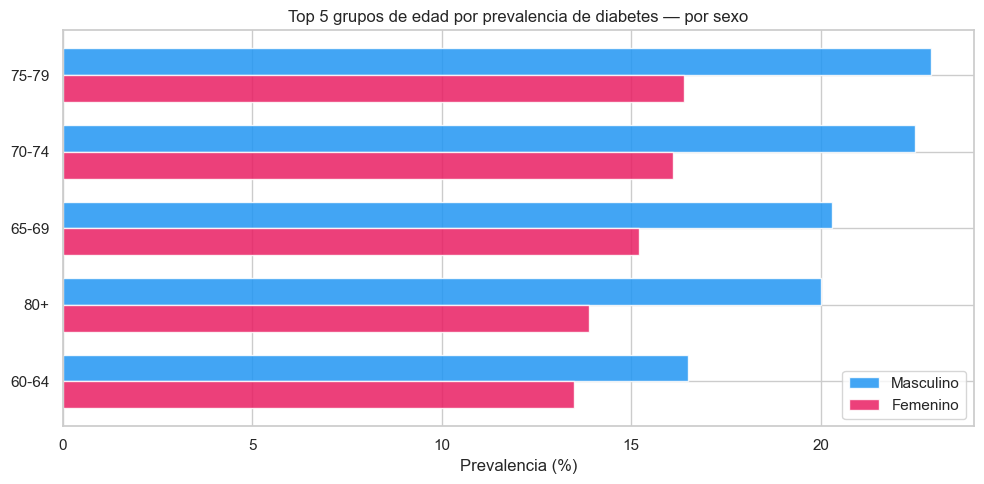

In [13]:
# Visualización — comparativa de prevalencia por grupo de edad y sexo
fig, ax = plt.subplots(figsize=(10, 5))

# Combinar ambos sexos en un solo gráfico agrupado
import numpy as np

grupos   = masculino['grupo_edad'].values[::-1]
prev_m   = masculino['prevalencia_pct'].values[::-1]
prev_f   = femenino['prevalencia_pct'].values[::-1]

x     = np.arange(len(grupos))
ancho = 0.35

ax.barh(x + ancho/2, prev_m, ancho, label='Masculino', color='#2196F3', alpha=0.85)
ax.barh(x - ancho/2, prev_f, ancho, label='Femenino',  color='#E91E63', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(grupos)
ax.set_xlabel('Prevalencia (%)')
ax.set_title('Top 5 grupos de edad por prevalencia de diabetes — por sexo')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Hallazgos clave

Conclusiones cuantificadas extraídas directamente de las queries SQL
sobre el dataset completo de 257.709 registros.

In [17]:
# Recuperar métricas clave de los notebooks anteriores para el resumen final
# Prevalencia global
prev_global = con.execute("""
    SELECT ROUND(SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1)
    FROM brfss
""").fetchone()[0]

# Grupo de edad con mayor prevalencia
edad_max = con.execute("""
    SELECT
        CASE _AGEG5YR
            WHEN 11 THEN '70-74' WHEN 12 THEN '75-79' WHEN 13 THEN '80+'
            WHEN 9  THEN '60-64' WHEN 10 THEN '65-69'
            ELSE CAST(CAST(_AGEG5YR AS INT) AS VARCHAR)
        END AS grupo,
        ROUND(SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS prev
    FROM brfss
    WHERE _AGEG5YR != -1.0
    GROUP BY _AGEG5YR
    ORDER BY prev DESC
    LIMIT 1
""").df()

# Prevalencia por IMC
bmi_stats = con.execute("""
    SELECT
        CASE _BMI5CAT WHEN 2 THEN 'Normopeso' WHEN 4 THEN 'Obesidad' END AS cat,
        ROUND(SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS prev
    FROM brfss
    WHERE _BMI5CAT IN (2, 4)
    GROUP BY _BMI5CAT
    ORDER BY _BMI5CAT
""").df()

# Hipertensión por clase
hiper = con.execute("""
    SELECT
        CASE WHEN DIABETE3 = 1.0 THEN 'Diabético' ELSE 'No diabético' END AS clase,
        ROUND(AVG(CASE WHEN BPHIGH4 != -1.0 THEN CASE WHEN BPHIGH4 = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct
    FROM brfss
    GROUP BY DIABETE3
    ORDER BY DIABETE3
""").df()

# Percentiles de dieta
p50_fruta_d  = resultado_percentiles[resultado_percentiles['clase'] == 'Diabético']['fruta_p50'].values[0]
p50_fruta_nd = resultado_percentiles[resultado_percentiles['clase'] == 'No diabético']['fruta_p50'].values[0]

# Ranking top 1 por sexo
top_m = resultado_ranking[(resultado_ranking['sexo'] == 'Masculino') & (resultado_ranking['rank_sexo'] == 1)].iloc[0]
top_f = resultado_ranking[(resultado_ranking['sexo'] == 'Femenino')  & (resultado_ranking['rank_sexo'] == 1)].iloc[0]

hiper_d  = hiper[hiper['clase'] == 'Diabético']['pct'].values[0]
hiper_nd = hiper[hiper['clase'] == 'No diabético']['pct'].values[0]
norm_prev = bmi_stats[bmi_stats['cat'] == 'Normopeso']['prev'].values[0]
obes_prev = bmi_stats[bmi_stats['cat'] == 'Obesidad']['prev'].values[0]

print('=' * 65)
print('HALLAZGOS CLAVE — BRFSS 2015 · 257.709 registros')
print('=' * 65)
print(f'  Prevalencia global de diabetes      : {prev_global}%')
print(f'  Grupo de edad con mayor prevalencia : {edad_max["grupo"].values[0]} años ({edad_max["prev"].values[0]}%)')
print(f'  Prevalencia normopeso vs obesidad   : {norm_prev}% vs {obes_prev}%')
print(f'  Hipertensión en diabéticos          : {hiper_d}% vs {hiper_nd}% (no diabéticos)')
print(f'  Mediana consumo fruta (P50)         : diabéticos={p50_fruta_d} | no diabéticos={p50_fruta_nd} porciones/día')
print(f'  Top grupo edad masculino            : {top_m["grupo_edad"]} años ({top_m["prevalencia_pct"]}%)')
print(f'  Top grupo edad femenino             : {top_f["grupo_edad"]} años ({top_f["prevalencia_pct"]}%)')
print('=' * 65)
print('Análisis completado')

HALLAZGOS CLAVE — BRFSS 2015 · 257.709 registros
  Prevalencia global de diabetes      : 11.0%
  Grupo de edad con mayor prevalencia : 75-79 años (19.0%)
  Prevalencia normopeso vs obesidad   : 4.7% vs 20.8%
  Hipertensión en diabéticos          : 73.2% vs 32.2% (no diabéticos)
  Mediana consumo fruta (P50)         : diabéticos=1.02 | no diabéticos=1.11 porciones/día
  Top grupo edad masculino            : 75-79 años (22.9%)
  Top grupo edad femenino             : 75-79 años (16.4%)
Análisis completado


## 4. Resumen de la ejecución

In [16]:
print('=' * 65)
print('RESUMEN — ANÁLISIS AVANZADO SQL')
print('=' * 65)
print(f'  Window functions ejecutadas : PERCENT_RANK(), ROW_NUMBER()')
print(f'  Particiones aplicadas       : PARTITION BY DIABETE3, PARTITION BY SEX')
print(f'  Registros analizados        : {df.shape[0]:,}')
print('=' * 65)
print('Siguiente paso: actualizar README con hallazgos clave y configurar CI/CD')

RESUMEN — ANÁLISIS AVANZADO SQL
  Window functions ejecutadas : PERCENT_RANK(), ROW_NUMBER()
  Particiones aplicadas       : PARTITION BY DIABETE3, PARTITION BY SEX
  Registros analizados        : 257,709
Siguiente paso: actualizar README con hallazgos clave y configurar CI/CD
